In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('Online_Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [8]:
c_invoices = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"{len(c_invoices):,}")


9,288


In [9]:
df = df.dropna(subset='CustomerID')

In [10]:
df = df.drop_duplicates()

In [11]:
returns = df[df['Quantity'] < 0].copy()

In [12]:
len(returns)

8872

In [13]:
real_sales = df[(df['Quantity']> 0) & (df['UnitPrice'] > 0)].copy()
real_sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [14]:
df.shape

(401604, 8)

In [15]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
df['TotalPrice'].describe()

count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

In [17]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [18]:
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [19]:
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: snapshot_date - x.max()),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

rfm['Recency'] = rfm['Recency'].dt.days.astype(int)

In [20]:
print(f"\nRFM cədvəli: {rfm.shape[0]:,} müştəri × {rfm.shape[1]} sütun")
rfm.head()


RFM cədvəli: 4,372 müştəri × 4 sütun


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [21]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1893.531433
std,100.765435,9.338754,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.795000
50%,50.000000,3.000000,644.070000
75%,143.000000,5.000000,1608.335000
max,374.000000,248.000000,279489.020000


In [22]:
extra = df.groupby('CustomerID').agg(
    CategoryDiversity=('StockCode', 'nunique')
)

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']


In [25]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,12346.0,326,2,0.00,0.000000
1,12347.0,2,7,4310.00,615.714286
2,12348.0,75,4,1797.24,449.310000
3,12349.0,19,1,1757.55,1757.550000
4,12350.0,310,1,334.40,334.400000


In [26]:
return_invoice = returns.groupby('CustomerID')['InvoiceNo'].nunique()
total_invoice = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [27]:
return_rate = (return_invoice / total_invoice).fillna(0)

In [28]:
return_rate

CustomerID
12346.0    0.500000
12347.0    0.000000
12348.0    0.000000
12349.0    0.000000
12350.0    0.000000
             ...   
18280.0    0.000000
18281.0    0.000000
18282.0    0.333333
18283.0    0.000000
18287.0    0.000000
Name: InvoiceNo, Length: 4372, dtype: float64

In [29]:
rfm.head

<bound method NDFrame.head of       CustomerID  Recency  Frequency  Monetary  AvgOrderValue
0        12346.0      326          2      0.00       0.000000
1        12347.0        2          7   4310.00     615.714286
2        12348.0       75          4   1797.24     449.310000
3        12349.0       19          1   1757.55    1757.550000
4        12350.0      310          1    334.40     334.400000
...          ...      ...        ...       ...            ...
4367     18280.0      278          1    180.60     180.600000
4368     18281.0      181          1     80.82      80.820000
4369     18282.0        8          3    176.60      58.866667
4370     18283.0        4         16   2045.53     127.845625
4371     18287.0       43          3   1837.28     612.426667

[4372 rows x 5 columns]>

In [30]:
rfm = rfm.merge(extra, on='CustomerID', how='left')
rfm['ReturnRate'] = rfm['CustomerID'].map(return_rate).fillna(0)

In [31]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CategoryDiversity,ReturnRate
0,12346.0,326,2,0.00,0.000000,1,0.5
1,12347.0,2,7,4310.00,615.714286,103,0.0
2,12348.0,75,4,1797.24,449.310000,22,0.0
3,12349.0,19,1,1757.55,1757.550000,73,0.0
4,12350.0,310,1,334.40,334.400000,17,0.0


In [32]:
rfm['Monetary'].skew()

np.float64(21.704784227644076)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler

# Clustering alqoritmləri (3 fərqli yanaşma müqayisə edəcəyik)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Hierarchical clustering üçün dendrogram (scipy)
from scipy.cluster.hierarchy import dendrogram, linkage

# Validation metrikləri — neçə cluster olmalıdır sualının CAVABI
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# Dimensionality reduction — 5 ölçünü 2 ölçüyə salıb şəkil çəkmək üçün
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Bonus: anomal müştəriləri tapmaq
from sklearn.ensemble import IsolationForest


c:\Users\MSI\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


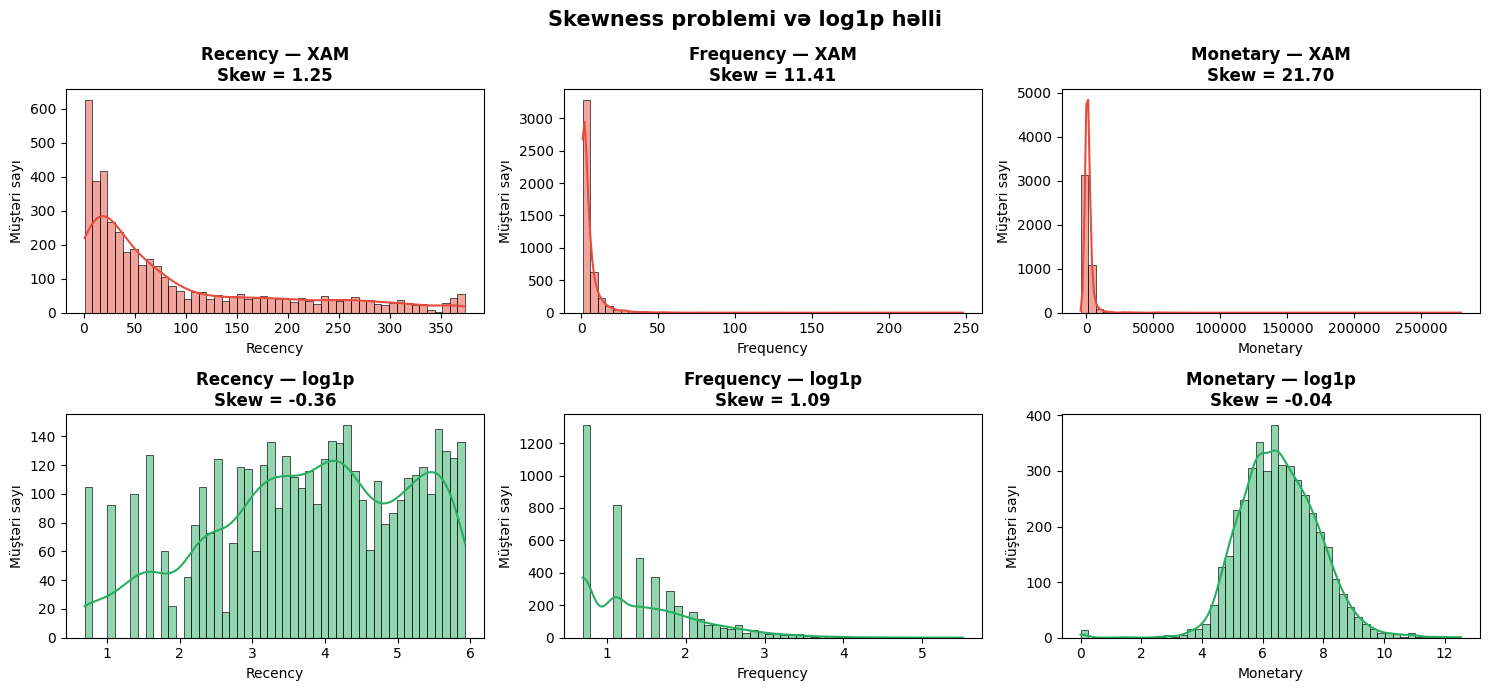

SKEW MÜQAYİSƏSİ
Feature            Xam   log1p sonra
Recency           1.25         -0.36
Frequency        11.41          1.09
Monetary         21.70         -0.04


c:\Users\MSI\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
rfm_core = rfm[['Recency', 'Frequency', 'Monetary']]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    # ÜST SIRA: xam data
    sns.histplot(rfm_core[col], bins=50, ax=axes[0, i], color='#e74c3c',
                 kde=True, discrete=False)
    axes[0, i].set_title(f'{col} — XAM\nSkew = {rfm_core[col].skew():.2f}', fontweight='bold')
    axes[0, i].set_ylabel('Müştəri sayı')

    # ALT SIRA: log1p
    logged = np.log1p(rfm_core[col])
    sns.histplot(logged, bins=50, ax=axes[1, i], color='#27ae60',
                 kde=True, discrete=False)
    axes[1, i].set_title(f'{col} — log1p\nSkew = {logged.skew():.2f}', fontweight='bold')
    axes[1, i].set_ylabel('Müştəri sayı')

plt.suptitle('Skewness problemi və log1p həlli', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("SKEW MÜQAYİSƏSİ")
print(f"{'Feature':<12}{'Xam':>10}{'log1p sonra':>14}")
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"{col:<12}{rfm_core[col].skew():>10.2f}{np.log1p(rfm_core[col]).skew():>14.2f}")

In [35]:
rfm_log = rfm_core.apply(np.log1p)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [36]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

In [37]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.372000e+03,4.372000e+03,4.331000e+03
mean,-2.291549e-16,6.013285e-17,1.706221e-16
std,1.000114e+00,1.000114e+00,1.000115e+00
min,-2.271351e+00,-1.018087e+00,-5.046235e+00
25%,-6.646671e-01,-1.018087e+00,-6.490132e-01
50%,9.687883e-02,-7.684082e-02,-4.948441e-02
75%,8.558901e-01,4.737529e-01,6.527273e-01
max,1.555763e+00,5.532988e+00,4.620693e+00


In [38]:
print("Scaling-dən SONRA (mean≈0, std≈1 olmalıdır):")
print(rfm_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].round(3))
print(f"\nClustering-ə gedən matris: {rfm_scaled.shape}")

Scaling-dən SONRA (mean≈0, std≈1 olmalıdır):
      Recency  Frequency  Monetary
mean   -0.000      0.000     0.000
std     1.000      1.000     1.000
min    -2.271     -1.018    -5.046
max     1.556      5.533     4.621

Clustering-ə gedən matris: (4372, 3)


In [39]:
K_range = range(2, 11)
results = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10)
    labels = km.fit_predict(rfm_scaled)
    results.append({
        'k': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(rfm_scaled, labels),
        'Davies-Buldin': davies_bouldin_score(rfm_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(rfm_scaled, labels)
    })

metrics = pd.DataFrame(results)

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
print("rfm dtypes:")
print(rfm.dtypes)

print("\nNaN sayı (rfm):")
print(rfm[['Recency','Frequency','Monetary']].isna().sum())

print("\nMənfi/sıfır dəyər var?")
for c in ['Recency','Frequency','Monetary']:
    print(f"  {c}: min = {rfm[c].min()}")

print(f"\nrfm_scaled NaN sayı: {np.isnan(rfm_scaled).sum()}")
print(f"rfm_scaled shape: {rfm_scaled.shape}")

rfm dtypes:
CustomerID           float64
Recency                int64
Frequency              int64
Monetary             float64
AvgOrderValue        float64
CategoryDiversity      int64
ReturnRate           float64
dtype: object

NaN sayı (rfm):
Recency      0
Frequency    0
Monetary     0
dtype: int64

Mənfi/sıfır dəyər var?
  Recency: min = 1
  Frequency: min = 1
  Monetary: min = -4287.63

rfm_scaled NaN sayı: 41
rfm_scaled shape: (4372, 3)


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler

# Clustering alqoritmləri (3 fərqli yanaşma müqayisə edəcəyik)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Hierarchical clustering üçün dendrogram (scipy)
from scipy.cluster.hierarchy import dendrogram, linkage

# Validation metrikləri — neçə cluster olmalıdır sualının CAVABI
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# Dimensionality reduction — 5 ölçünü 2 ölçüyə salıb şəkil çəkmək üçün
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Bonus: anomal müştəriləri tapmaq
from sklearn.ensemble import IsolationForest

In [41]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler

# ── Addım 1: yüklə
df = pd.read_excel('Online_Retail.xlsx')
print(f"Xam: {len(df):,}")

# ── Addım 2: TƏMİZLƏMƏ (bu addım əvvəl atlanmışdı!)
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df.drop_duplicates()

returns = df[df['Quantity'] < 0].copy()          # ReturnRate üçün saxla

df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Təmiz: {len(df_clean):,}")
print(f"Müştəri: {df_clean['CustomerID'].nunique():,}   ← 4,338 olmalıdır")

# ── Addım 3: RFM
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: snapshot_date - x.max()),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Recency'] = rfm['Recency'].dt.days.astype(int)     # Timedelta → gün

# Bonus feature-lar
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
extra = df_clean.groupby('CustomerID').agg(CategoryDiversity=('StockCode','nunique'))
rfm = rfm.merge(extra, on='CustomerID', how='left')

return_inv = returns.groupby('CustomerID')['InvoiceNo'].nunique()
total_inv  = df.groupby('CustomerID')['InvoiceNo'].nunique()
rfm['ReturnRate'] = rfm['CustomerID'].map(return_inv / total_inv).fillna(0)

# ── YOXLAMA — hamısı düz olmalıdır
print("\n" + "="*45)
print(f"Müştəri sayı : {len(rfm):,}      → 4,338 ✔")
print(f"Recency  min : {rfm['Recency'].min()}        → müsbət ✔")
print(f"Monetary min : {rfm['Monetary'].min():.2f}   → MÜSBƏT olmalıdır ✔")
print(f"NaN sayı     : {rfm[['Recency','Frequency','Monetary']].isna().sum().sum()}        → 0 ✔")
print("="*45)

# ── Addım 4: log → scale
rfm_core   = rfm[['Recency','Frequency','Monetary']].astype(float)
rfm_log    = rfm_core.apply(np.log1p)
rfm_scaled = StandardScaler().fit_transform(rfm_log)

print(f"\nrfm_scaled shape : {rfm_scaled.shape}   → (4338, 3) ✔")
print(f"NaN sayı         : {np.isnan(rfm_scaled).sum()}          → 0 ✔")
rfm.head()

Xam: 541,909
Təmiz: 392,692
Müştəri: 4,338   ← 4,338 olmalıdır

Müştəri sayı : 4,338      → 4,338 ✔
Recency  min : 1        → müsbət ✔
Monetary min : 3.75   → MÜSBƏT olmalıdır ✔
NaN sayı     : 0        → 0 ✔

rfm_scaled shape : (4338, 3)   → (4338, 3) ✔
NaN sayı         : 0          → 0 ✔


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CategoryDiversity,ReturnRate
0,12346,326,1,77183.60,77183.600000,1,0.5
1,12347,2,7,4310.00,615.714286,103,0.0
2,12348,75,4,1797.24,449.310000,22,0.0
3,12349,19,1,1757.55,1757.550000,73,0.0
4,12350,310,1,334.40,334.400000,17,0.0


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K_range = range(2, 11)
results = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    results.append({
        'k': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(rfm_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(rfm_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(rfm_scaled, labels)
    })

metrics = pd.DataFrame(results).set_index('k')
print("Sütunlar:", metrics.columns.tolist())   # 4 sütun olmalıdır
metrics.round(4)

Sütunlar: ['Inertia', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']


,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,6483.5894,0.4328,0.8925,4367.3231
3,4869.4886,0.3365,1.0483,3625.3034
4,3939.0494,0.3375,1.0086,3328.3383
5,3296.7087,0.3162,0.9878,3192.9771
6,2855.7641,0.3124,1.0210,3081.8919
7,2548.8202,0.3092,0.9823,2963.7935
8,2336.3411,0.3033,0.9892,2827.0676
9,2156.0057,0.2811,1.0193,2725.1963
10,2005.7462,0.2767,1.0268,2639.2905


In [46]:
metrics

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,6483.589425,0.432827,0.892499,4367.323098
3,4869.488629,0.336517,1.048336,3625.303442
4,3939.049382,0.337517,1.008648,3328.338320
5,3296.708708,0.316200,0.987779,3192.977083
6,2855.764068,0.312409,1.020962,3081.891934
7,2548.820245,0.309186,0.982334,2963.793543
8,2336.341054,0.303275,0.989165,2827.067611
9,2156.005673,0.281085,1.019266,2725.196267
10,2005.746236,0.276659,1.026838,2639.290467


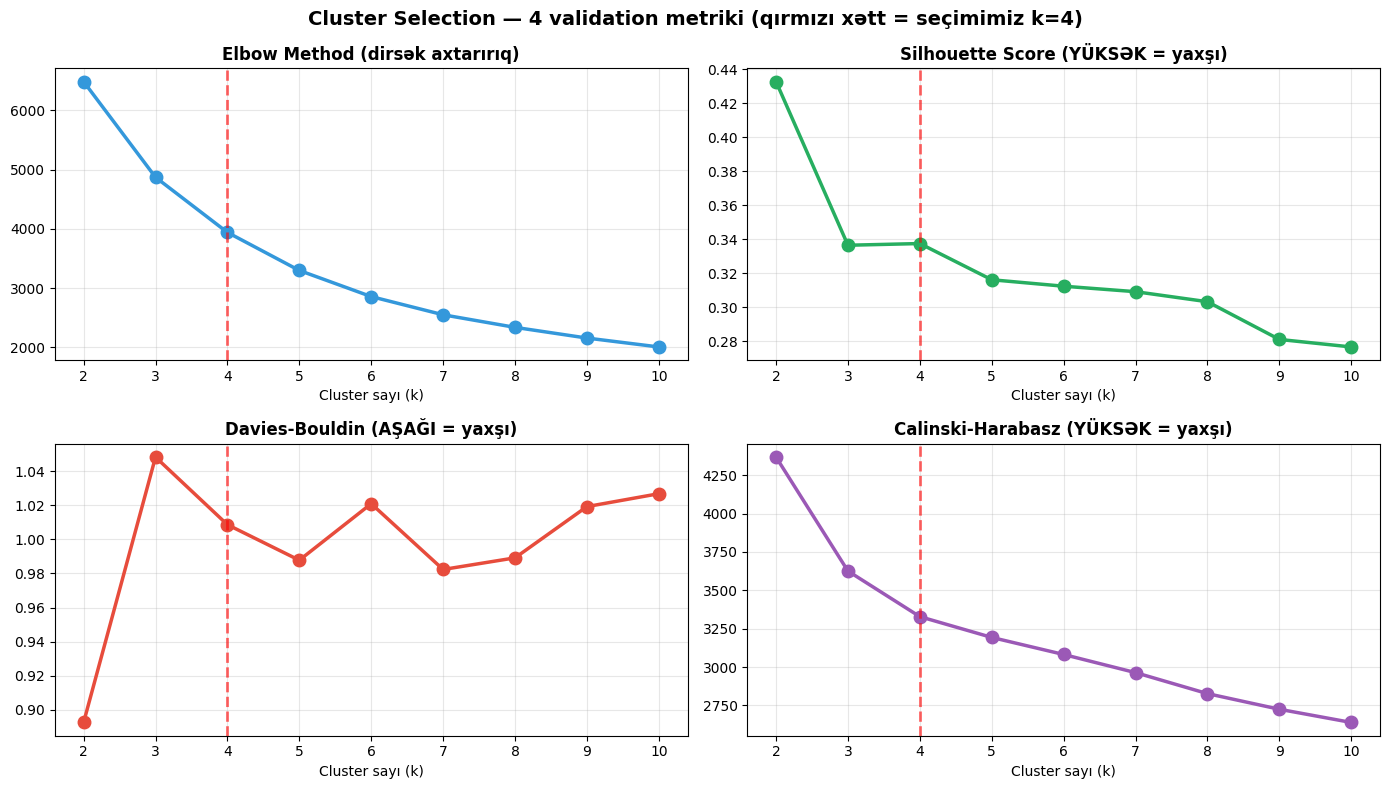

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plots = [
    ('Inertia',           'Elbow Method (dirsək axtarırıq)',      '#3498db', 'aşağı, dirsəkdə'),
    ('Silhouette',        'Silhouette Score (YÜKSƏK = yaxşı)',    '#27ae60', 'yüksək'),
    ('Davies-Bouldin',    'Davies-Bouldin (AŞAĞI = yaxşı)',       '#e74c3c', 'aşağı'),
    ('Calinski-Harabasz', 'Calinski-Harabasz (YÜKSƏK = yaxşı)',   '#9b59b6', 'yüksək'),
]

for ax, (col, title, color, _) in zip(axes.flat, plots):
    ax.plot(metrics.index, metrics[col], 'o-', color=color, linewidth=2.5, markersize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster sayı (k)')
    ax.set_xticks(list(K_range))
    ax.axvline(4, color='red', linestyle='--', alpha=0.6, linewidth=2)   # bizim seçim
    ax.grid(alpha=0.3)

plt.suptitle('Cluster Selection — 4 validation metriki (qırmızı xətt = seçimimiz k=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(rfm_scaled)

hier = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hc = hier.fit_predict(rfm_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_db = dbscan.fit_predict(rfm_scaled)

n_db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print("K-MEANS")
print(f"  Cluster sayı : 4")
print(f"  Silhouette   : {silhouette_score(rfm_scaled, labels_km):.4f}")
print(f"  Davies-Bould.: {davies_bouldin_score(rfm_scaled, labels_km):.4f}")

print("\nHIERARCHICAL (Ward)")
print(f"  Cluster sayı : 4")
print(f"  Silhouette   : {silhouette_score(rfm_scaled, labels_hc):.4f}")
print(f"  Davies-Bould.: {davies_bouldin_score(rfm_scaled, labels_hc):.4f}")

print("\nDBSCAN (eps=0.5, min_samples=10)")
print(f"  Cluster sayı : {n_db_clusters}")
print(f"  Noise (outlier): {n_noise} müştəri ({n_noise/len(rfm)*100:.1f}%)")

mask = labels_db != -1
if n_db_clusters > 1:
    print(f"  Silhouette (noise-suz): {silhouette_score(rfm_scaled[mask], labels_db[mask]):.4f}")


K-MEANS
  Cluster sayı : 4
  Silhouette   : 0.3375
  Davies-Bould.: 1.0086

HIERARCHICAL (Ward)
  Cluster sayı : 4
  Silhouette   : 0.2800
  Davies-Bould.: 1.0992

DBSCAN (eps=0.5, min_samples=10)
  Cluster sayı : 2
  Noise (outlier): 79 müştəri (1.8%)
  Silhouette (noise-suz): 0.2939


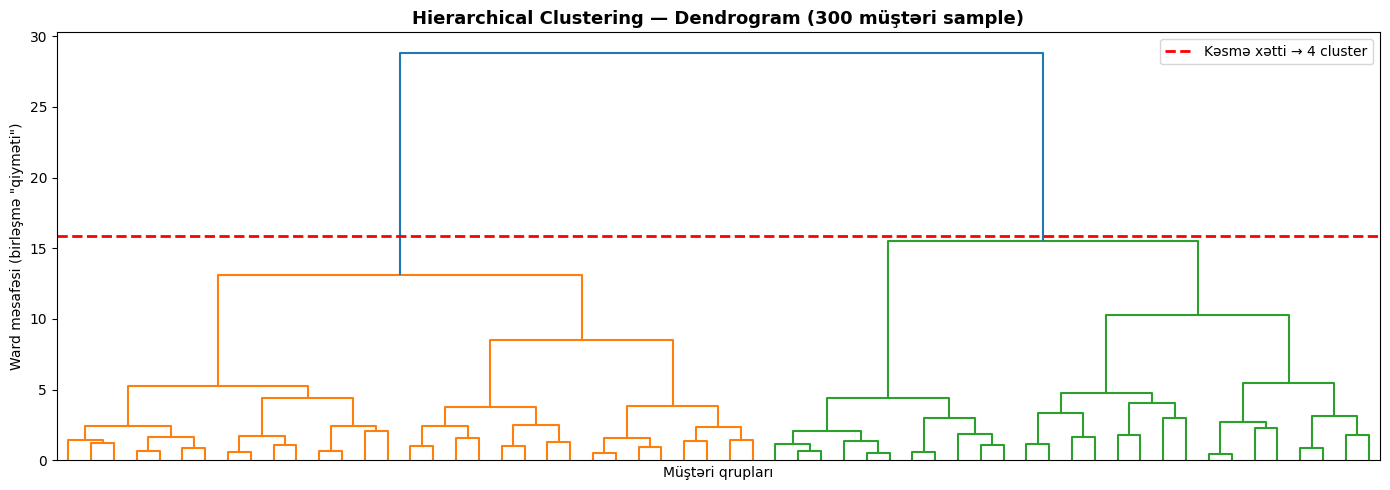

In [52]:
np.random.seed(42)
sample_idx = np.random.choice(len(rfm_scaled), 300, replace=False)
Z = linkage(rfm_scaled[sample_idx], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True, color_threshold=0.55*max(Z[:,2]))
plt.axhline(y=0.55*max(Z[:,2]), color='red', linestyle='--', linewidth=2,
            label='Kəsmə xətti → 4 cluster')
plt.title('Hierarchical Clustering — Dendrogram (300 müştəri sample)',
          fontsize=13, fontweight='bold')
plt.xlabel('Müştəri qrupları')
plt.ylabel('Ward məsafəsi (birləşmə "qiyməti")')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
rfm['Cluster'] = labels_km

print("Cluster ölçüləri:")
sizes = rfm['Cluster'].value_counts().sort_index()
for cl, n in sizes.items():
    print(f"  Cluster {cl}: {n:>5,} müştəri  ({n/len(rfm)*100:>5.1f}%)  {'█'*int(n/40)}")

Cluster ölçüləri:
  Cluster 0:   713 müştəri  ( 16.4%)  █████████████████
  Cluster 1: 1,622 müştəri  ( 37.4%)  ████████████████████████████████████████
  Cluster 2:   837 müştəri  ( 19.3%)  ████████████████████
  Cluster 3: 1,166 müştəri  ( 26.9%)  █████████████████████████████


In [55]:
profile = rfm.groupby('Cluster').agg(
    Müştəri_sayı      = ('CustomerID', 'count'),
    Recency_ort       = ('Recency', 'mean'),
    Frequency_ort     = ('Frequency', 'mean'),
    Monetary_ort      = ('Monetary', 'mean'),
    Monetary_median   = ('Monetary', 'median'),
    Orta_çek          = ('AvgOrderValue', 'mean'),
    Məhsul_çeşidi     = ('CategoryDiversity', 'mean'),
    Return_faizi      = ('ReturnRate', 'mean'),
).round(1)

profile

,Müştəri_sayı,Recency_ort,Frequency_ort,Monetary_ort,Monetary_median,Orta_çek,Məhsul_çeşidi,Return_faizi
Cluster,,,,,,,,
0,713,12.2,13.8,8088.0,3722.8,623.8,154.9,0.2
1,1622,181.5,1.3,341.0,296.1,282.5,22.0,0.1
2,837,17.7,2.2,557.3,480.3,278.3,42.8,0.1
3,1166,71.6,4.1,1801.8,1345.2,579.7,72.8,0.1


In [57]:
revenue = rfm.groupby('Cluster')['Monetary'].sum()
profile['Gəlir_payı_%'] = ((revenue / revenue.sum()) * 100).round(1)
profile['Müştəri_payı_%'] = (profile['Müştəri_sayı'] / len(rfm) * 100).round(1)


In [58]:
profile

,Müştəri_sayı,Recency_ort,Frequency_ort,Monetary_ort,Monetary_median,Orta_çek,Məhsul_çeşidi,Return_faizi,Gəlir_payı_%,Müştəri_payı_%
Cluster,,,,,,,,,,
0,713,12.2,13.8,8088.0,3722.8,623.8,154.9,0.2,64.9,16.4
1,1622,181.5,1.3,341.0,296.1,282.5,22.0,0.1,6.2,37.4
2,837,17.7,2.2,557.3,480.3,278.3,42.8,0.1,5.2,19.3
3,1166,71.6,4.1,1801.8,1345.2,579.7,72.8,0.1,23.6,26.9


In [59]:
segment_names = {
    0: 'Champions',
    1: 'At-Risk / Lost',
    2: 'New / Promising',
    3: 'Loyal'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)
colors = {
    'Champions':       '#27ae60',   # yaşıl  — sağlam
    'Loyal':           '#3498db',   # mavi   — sabit
    'New / Promising': '#f39c12',   # narıncı— potensial
    'At-Risk / Lost':  '#e74c3c',   # qırmızı— təhlükə
}

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].head(10)

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,326,1,77183.60,Loyal
1,12347,2,7,4310.00,Champions
2,12348,75,4,1797.24,Loyal
3,12349,19,1,1757.55,New / Promising
4,12350,310,1,334.40,At-Risk / Lost
5,12352,36,8,2506.04,Loyal
6,12353,204,1,89.00,At-Risk / Lost
7,12354,232,1,1079.40,At-Risk / Lost
8,12355,214,1,459.40,At-Risk / Lost
9,12356,23,3,2811.43,Loyal


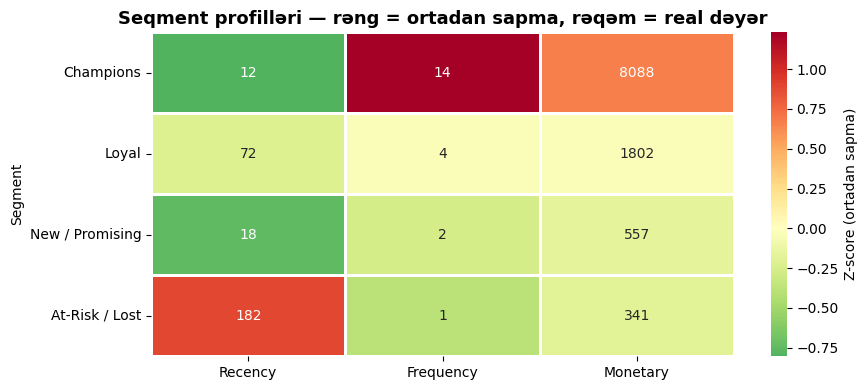

Recency-də QIRMIZI = pis (çoxdan gəlməyib)
Frequency/Monetary-də QIRMIZI = ...əslində yaxşı sayılmalıdır,
amma cmap tərsdir (RdYlGn_r) — ona görə Recency düzgün oxunur.
Champions: Recency AŞAĞI (yaşıl), F və M YÜKSƏK.


In [60]:
heat = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
heat_z = (heat - rfm[['Recency','Frequency','Monetary']].mean()) / rfm[['Recency','Frequency','Monetary']].std()
heat_z = heat_z.reindex(['Champions', 'Loyal', 'New / Promising', 'At-Risk / Lost'])

plt.figure(figsize=(9, 4))
sns.heatmap(heat_z, annot=heat.reindex(heat_z.index).round(0), fmt='g',
            cmap='RdYlGn_r', center=0, linewidths=2,
            cbar_kws={'label': 'Z-score (ortadan sapma)'})
plt.title('Seqment profilləri — rəng = ortadan sapma, rəqəm = real dəyər',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Recency-də QIRMIZI = pis (çoxdan gəlməyib)")
print("Frequency/Monetary-də QIRMIZI = ...əslində yaxşı sayılmalıdır,")
print("amma cmap tərsdir (RdYlGn_r) — ona görə Recency düzgün oxunur.")
print("Champions: Recency AŞAĞI (yaşıl), F və M YÜKSƏK.")

In [61]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(rfm_scaled)

rfm['PC1'] = coords[:, 0]
rfm['PC2'] = coords[:, 1]

var = pca.explained_variance_ratio_
print(f"PC1 informasiyanın {var[0]*100:.1f}%-ini saxlayır")
print(f"PC2 informasiyanın {var[1]*100:.1f}%-ini saxlayır")
print(f"CƏMİ: {var.sum()*100:.1f}%  →  2D şəkil orijinal strukturun {var.sum()*100:.0f}%-ini düzgün göstərir")

# PC-lərin mənası nədir? Loading-lərə baxaq
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'],
                        index=['Recency', 'Frequency', 'Monetary'])
print("\nPCA Loadings (hansı feature hansı oxu formalaşdırır):")
print(loadings.round(3))

PC1 informasiyanın 75.1%-ini saxlayır
PC2 informasiyanın 18.8%-ini saxlayır
CƏMİ: 93.9%  →  2D şəkil orijinal strukturun 94%-ini düzgün göstərir

PCA Loadings (hansı feature hansı oxu formalaşdırır):
             PC1    PC2
Recency   -0.512  0.850
Frequency  0.618  0.261
Monetary   0.597  0.458


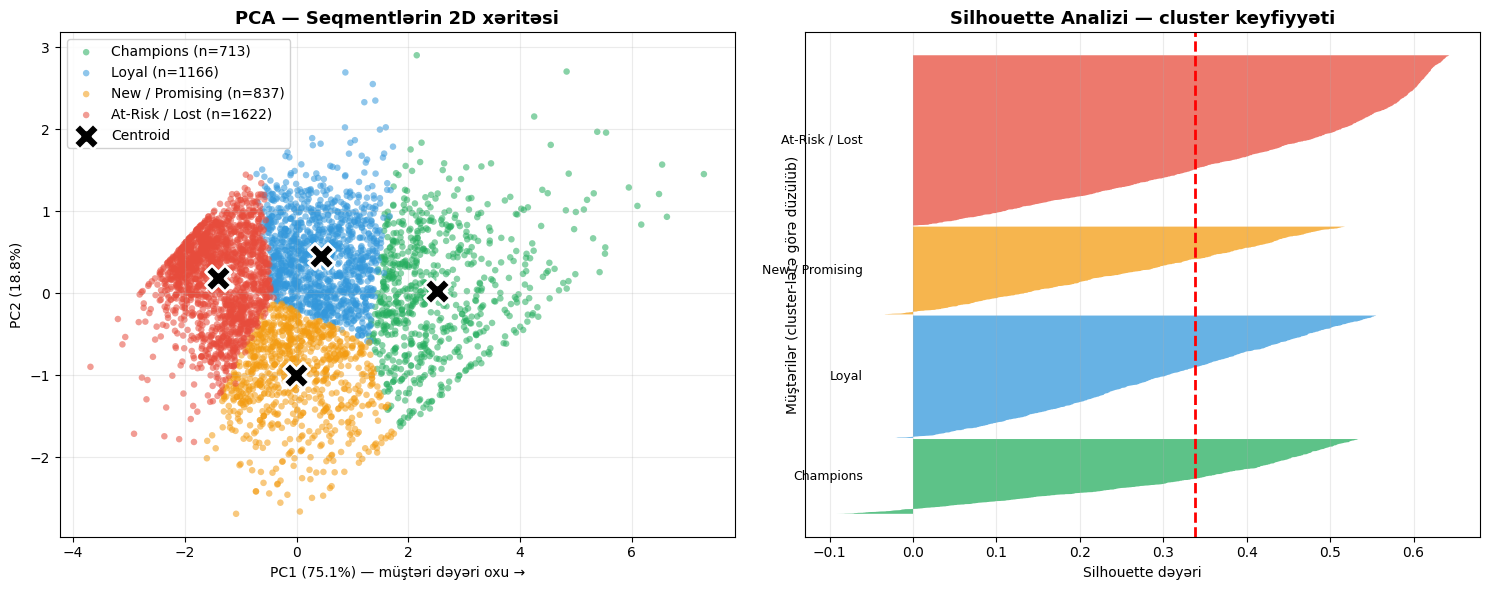

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# SOL: PCA scatter, seqmentlərə görə rənglənib
for seg, col in colors.items():
    sub = rfm[rfm['Segment'] == seg]
    axes[0].scatter(sub['PC1'], sub['PC2'], c=col, label=f"{seg} (n={len(sub)})",
                    alpha=0.55, s=22, edgecolors='none')

# Centroid-ləri PCA məkanına köçürürük
cent = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(cent[:, 0], cent[:, 1], c='black', marker='X', s=350,
                edgecolors='white', linewidths=2, label='Centroid', zorder=10)

axes[0].set_xlabel(f'PC1 ({var[0]*100:.1f}%) — müştəri dəyəri oxu →')
axes[0].set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
axes[0].set_title('PCA — Seqmentlərin 2D xəritəsi', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', framealpha=0.9)
axes[0].grid(alpha=0.25)

# SAĞ: Silhouette plot — hər müştərinin "öz cluster-inə uyğunluğu"
sil_vals = silhouette_samples(rfm_scaled, labels_km)
avg_sil = silhouette_score(rfm_scaled, labels_km)

y_low = 10
for i, seg in enumerate(['Champions', 'Loyal', 'New / Promising', 'At-Risk / Lost']):
    cl = [k for k, v in segment_names.items() if v == seg][0]
    vals = np.sort(sil_vals[labels_km == cl])
    y_high = y_low + len(vals)
    axes[1].fill_betweenx(np.arange(y_low, y_high), 0, vals,
                          facecolor=colors[seg], alpha=0.75, label=seg)
    axes[1].text(-0.06, y_low + len(vals)/2, seg, fontsize=9, ha='right', va='center')
    y_low = y_high + 10

axes[1].axvline(avg_sil, color='red', linestyle='--', linewidth=2,
                label=f'Ortalama = {avg_sil:.3f}')
axes[1].set_xlabel('Silhouette dəyəri')
axes[1].set_ylabel('Müştərilər (cluster-lərə görə düzülüb)')
axes[1].set_title('Silhouette Analizi — cluster keyfiyyəti', fontsize=13, fontweight='bold')
axes[1].set_yticks([])
axes[1].grid(alpha=0.25, axis='x')

plt.tight_layout()
plt.show()

In [63]:
iso = IsolationForest(contamination=0.02, random_state=42, n_estimators=200)
iso_labels = iso.fit_predict(rfm_scaled)
rfm['Outlier_ISO'] = (iso_labels == -1)

# Metod 2: DBSCAN noise nöqtələri (yuxarıda artıq hesablamışdıq)
rfm['Outlier_DBSCAN'] = (labels_db == -1)

# Hər ikisinin razılaşdığı → ən güclü siqnal
rfm['Outlier_Both'] = rfm['Outlier_ISO'] & rfm['Outlier_DBSCAN']

print(f"Isolation Forest tapdı : {rfm['Outlier_ISO'].sum()} müştəri")
print(f"DBSCAN noise           : {rfm['Outlier_DBSCAN'].sum()} müştəri")
print(f"HƏR İKİSİ razılaşdı    : {rfm['Outlier_Both'].sum()} müştəri  ← ən etibarlı")

print("\nOutlier-lərin profili (Isolation Forest):")
comp = pd.DataFrame({
    'Outlier':  rfm[rfm['Outlier_ISO']][['Recency','Frequency','Monetary']].mean(),
    'Normal':   rfm[~rfm['Outlier_ISO']][['Recency','Frequency','Monetary']].mean(),
}).round(1)
comp['Fərq (×)'] = (comp['Outlier'] / comp['Normal']).round(1)
print(comp)

Isolation Forest tapdı : 87 müştəri
DBSCAN noise           : 79 müştəri
HƏR İKİSİ razılaşdı    : 50 müştəri  ← ən etibarlı

Outlier-lərin profili (Isolation Forest):
           Outlier  Normal  Fərq (×)
Recency       40.2    93.6       0.4
Frequency     35.6     3.6       9.9
Monetary   36656.3  1340.4      27.3


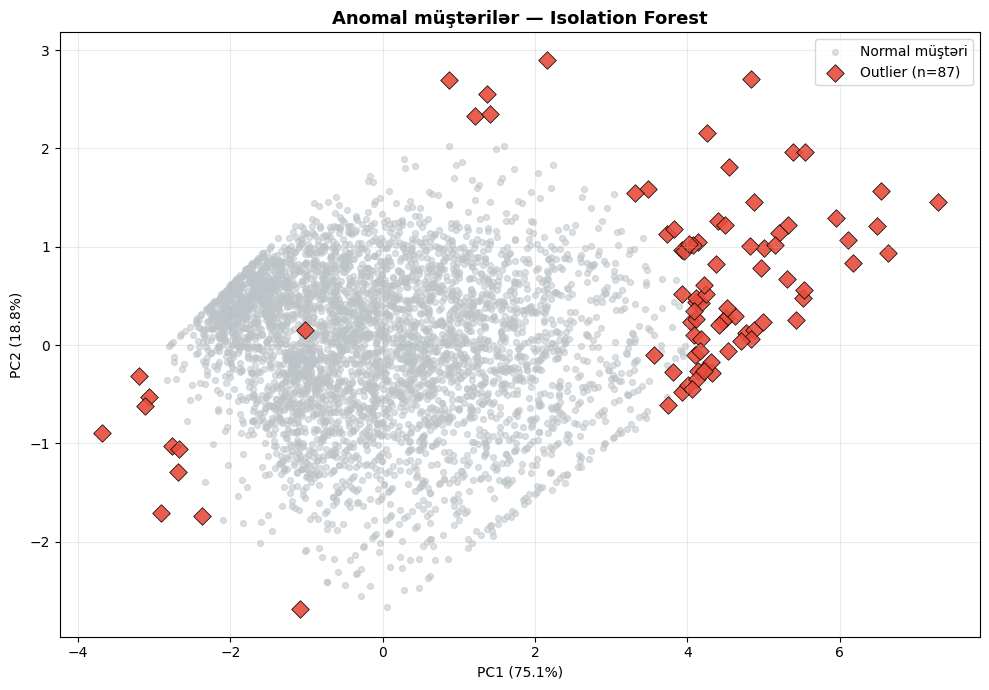

Ən böyük 5 outlier (Monetary-yə görə):
 CustomerID  Recency  Frequency  Monetary   Segment
      14646        2         73 280206.02 Champions
      18102        1         60 259657.30 Champions
      17450        8         46 194390.79 Champions
      16446        1          2 168472.50 Champions
      14911        1        201 143711.17 Champions


In [64]:
plt.figure(figsize=(10, 7))

plt.scatter(rfm.loc[~rfm['Outlier_ISO'], 'PC1'], rfm.loc[~rfm['Outlier_ISO'], 'PC2'],
            c='#bdc3c7', s=18, alpha=0.5, label='Normal müştəri')
plt.scatter(rfm.loc[rfm['Outlier_ISO'], 'PC1'], rfm.loc[rfm['Outlier_ISO'], 'PC2'],
            c='#e74c3c', s=80, alpha=0.9, marker='D', edgecolors='black',
            linewidths=0.6, label=f"Outlier (n={rfm['Outlier_ISO'].sum()})")

plt.xlabel(f'PC1 ({var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var[1]*100:.1f}%)')
plt.title('Anomal müştərilər — Isolation Forest', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Ən ekstremal 5-i
print("Ən böyük 5 outlier (Monetary-yə görə):")
top_out = rfm[rfm['Outlier_ISO']].nlargest(5, 'Monetary')[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']]
print(top_out.to_string(index=False))

In [71]:


seg_order = ['Champions', 'Loyal', 'New / Promising', 'At-Risk / Lost']
summary = pd.DataFrame({
    'Müştəri': rfm.groupby('Segment').size(),
    'Müştəri %': (rfm.groupby('Segment').size() / len(rfm) * 100).round(1),
    'Gəlir £': rfm.groupby('Segment')['Monetary'].sum().round(0),
    'Gəlir %': (rfm.groupby('Segment')['Monetary'].sum() /
                rfm['Monetary'].sum() * 100).round(1),
    'Orta Recency': rfm.groupby('Segment')['Recency'].mean().round(0),
    'Orta Frequency': rfm.groupby('Segment')['Frequency'].mean().round(1),
    'Orta Monetary': rfm.groupby('Segment')['Monetary'].mean().round(0),
}).reindex(seg_order)

# ROI göstəricisi: gəlir payı / müştəri payı
summary['Dəyər indeksi'] = (summary['Gəlir %'] / summary['Müştəri %']).round(2)

print("YEKUN SEQMENT XÜLASƏSİ")
print("="*95)
print(summary.to_string())
print("="*95)
print("\n'Dəyər indeksi' = Gəlir payı ÷ Müştəri payı")
print("  > 1.0 → bu seqment öz çəkisindən ARTIQ gəlir gətirir")
print("  < 1.0 → bu seqment öz çəkisindən AZ gəlir gətirir")

YEKUN SEQMENT XÜLASƏSİ
                 Müştəri  Müştəri %    Gəlir £  Gəlir %  Orta Recency  Orta Frequency  Orta Monetary  Dəyər indeksi
Segment                                                                                                            
Champions            713       16.4  5766757.0     64.9          12.0            13.8         8088.0           3.96
Loyal               1166       26.9  2100873.0     23.6          72.0             4.1         1802.0           0.88
New / Promising      837       19.3   466479.0      5.2          18.0             2.2          557.0           0.27
At-Risk / Lost      1622       37.4   553100.0      6.2         182.0             1.3          341.0           0.17

'Dəyər indeksi' = Gəlir payı ÷ Müştəri payı
  > 1.0 → bu seqment öz çəkisindən ARTIQ gəlir gətirir
  < 1.0 → bu seqment öz çəkisindən AZ gəlir gətirir


In [72]:
output = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
              'AvgOrderValue', 'CategoryDiversity', 'ReturnRate',
              'Cluster', 'Segment', 'Outlier_ISO']].copy()
output.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
                  'AvgOrderValue', 'CategoryDiversity', 'ReturnRate',
                  'ClusterID', 'Segment', 'IsOutlier']

output.to_csv('customer_segments.csv', index=False)
summary.to_csv('segment_summary.csv')

print(f"customer_segments.csv  →  {len(output):,} müştəri, etiketlənmiş")
print(f"segment_summary.csv    →  seqment xülasəsi")
print("\nPipeline tamamlandı ✅")
output.head()

customer_segments.csv  →  4,338 müştəri, etiketlənmiş
segment_summary.csv    →  seqment xülasəsi

Pipeline tamamlandı ✅


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CategoryDiversity,ReturnRate,ClusterID,Segment,IsOutlier
0,12346,326,1,77183.60,77183.600000,1,0.5,3,Loyal,True
1,12347,2,7,4310.00,615.714286,103,0.0,0,Champions,False
2,12348,75,4,1797.24,449.310000,22,0.0,3,Loyal,False
3,12349,19,1,1757.55,1757.550000,73,0.0,2,New / Promising,False
4,12350,310,1,334.40,334.400000,17,0.0,1,At-Risk / Lost,False
